In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import warnings
warnings.filterwarnings('ignore')
print("Libraries imported!")

Libraries imported!


In [12]:
from sklearn.datasets import fetch_openml
data = fetch_openml(name='diabetes', version=1, as_frame=True)
df = data.frame
print("Dataset loaded!")

Dataset loaded!


In [13]:
print("Shape:", df.shape)
print()
print("Column Names:", df.columns.tolist())
print()
print("First 5 rows:")
df.head()

Shape: (768, 9)

Column Names: ['preg', 'plas', 'pres', 'skin', 'insu', 'mass', 'pedi', 'age', 'class']

First 5 rows:


,preg,plas,pres,skin,insu,mass,pedi,age,class
0,6,148,72,35,0,33.6,0.627,50,tested_positive
1,1,85,66,29,0,26.6,0.351,31,tested_negative
2,8,183,64,0,0,23.3,0.672,32,tested_positive
3,1,89,66,23,94,28.1,0.167,21,tested_negative
4,0,137,40,35,168,43.1,2.288,33,tested_positive


In [14]:
# Selecting only important features
features = ['preg', 'plas', 'pres', 'skin', 'insu', 'mass', 'pedi', 'age']
target = 'class'

X = df[features]
y = df[target]

print("Selected Features:", features)
print("Target column:", target)
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Features extracted! ")

Selected Features: ['preg', 'plas', 'pres', 'skin', 'insu', 'mass', 'pedi', 'age']
Target column: class
X shape: (768, 8)
y shape: (768,)
Features extracted! 


In [15]:
print("Missing values before:")
print(X.isnull().sum())

X = X.fillna(X.median())

print()
print("Missing values after:")
print(X.isnull().sum())
print("Missing values handled! ")

Missing values before:
preg    0
plas    0
pres    0
skin    0
insu    0
mass    0
pedi    0
age     0
dtype: int64

Missing values after:
preg    0
plas    0
pres    0
skin    0
insu    0
mass    0
pedi    0
age     0
dtype: int64
Missing values handled! 


In [16]:
le = LabelEncoder()
y = le.fit_transform(y)
print("Classes after encoding:", le.classes_)
print("Label encoding done! ")

Classes after encoding: ['tested_negative' 'tested_positive']
Label encoding done! 


In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print("Train-test split done! ✅")

Training samples: 614
Testing samples: 154
Train-test split done! ✅


In [18]:
lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)

print("Logistic Regression Results:")
print("Accuracy :", round(accuracy_score(y_test, lr_pred), 2))
print("Precision:", round(precision_score(y_test, lr_pred), 2))
print("Recall   :", round(recall_score(y_test, lr_pred), 2))
print("F1 Score :", round(f1_score(y_test, lr_pred), 2))
print("Logistic Regression done! ✅")

Logistic Regression Results:
Accuracy : 0.75
Precision: 0.65
Recall   : 0.67
F1 Score : 0.66
Logistic Regression done! ✅


In [19]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

print("Decision Tree Results:")
print("Accuracy :", round(accuracy_score(y_test, dt_pred), 2))
print("Precision:", round(precision_score(y_test, dt_pred), 2))
print("Recall   :", round(recall_score(y_test, dt_pred), 2))
print("F1 Score :", round(f1_score(y_test, dt_pred), 2))
print("Decision Tree done! ✅")

Decision Tree Results:
Accuracy : 0.75
Precision: 0.62
Recall   : 0.73
F1 Score : 0.67
Decision Tree done! ✅


In [20]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
knn_pred = knn.predict(X_test_scaled)

print("KNN Results:")
print("Accuracy :", round(accuracy_score(y_test, knn_pred), 2))
print("Precision:", round(precision_score(y_test, knn_pred), 2))
print("Recall   :", round(recall_score(y_test, knn_pred), 2))
print("F1 Score :", round(f1_score(y_test, knn_pred), 2))
print("KNN done! ✅")

KNN Results:
Accuracy : 0.69
Precision: 0.58
Recall   : 0.51
F1 Score : 0.54
KNN done! ✅


In [21]:
results = {
    'Algorithm': ['Logistic Regression', 'Decision Tree', 'KNN'],
    'Accuracy':  [round(accuracy_score(y_test, lr_pred), 2),
                  round(accuracy_score(y_test, dt_pred), 2),
                  round(accuracy_score(y_test, knn_pred), 2)],
    'Precision': [round(precision_score(y_test, lr_pred), 2),
                  round(precision_score(y_test, dt_pred), 2),
                  round(precision_score(y_test, knn_pred), 2)],
    'Recall':    [round(recall_score(y_test, lr_pred), 2),
                  round(recall_score(y_test, dt_pred), 2),
                  round(recall_score(y_test, knn_pred), 2)],
    'F1 Score':  [round(f1_score(y_test, lr_pred), 2),
                  round(f1_score(y_test, dt_pred), 2),
                  round(f1_score(y_test, knn_pred), 2)]
}
results_df = pd.DataFrame(results)
print("📊 Final Comparison:")
print(results_df)

📊 Final Comparison:
             Algorithm  Accuracy  Precision  Recall  F1 Score
0  Logistic Regression      0.75       0.65    0.67      0.66
1        Decision Tree      0.75       0.62    0.73      0.67
2                  KNN      0.69       0.58    0.51      0.54


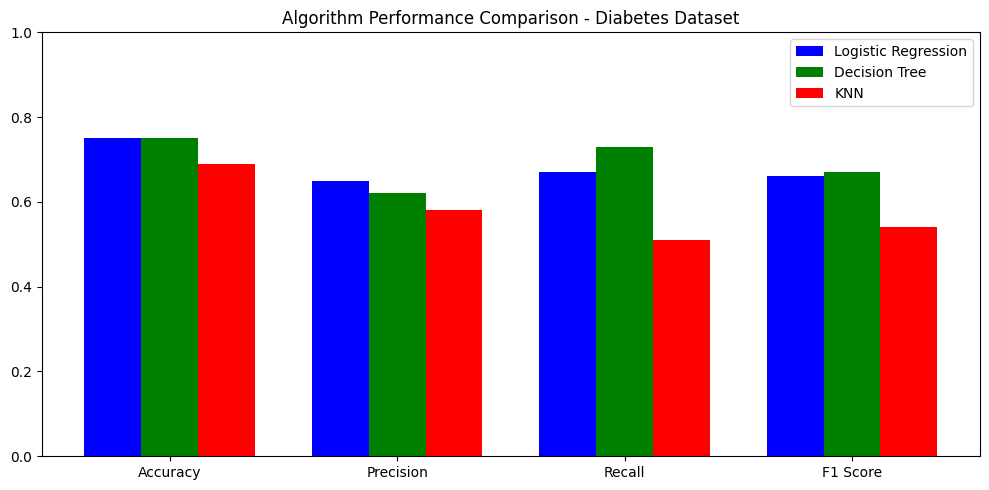

Chart done! ✅


In [22]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
lr_scores =  [results_df.iloc[0][m] for m in metrics]
dt_scores =  [results_df.iloc[1][m] for m in metrics]
knn_scores = [results_df.iloc[2][m] for m in metrics]

x = range(len(metrics))
plt.figure(figsize=(10, 5))
plt.bar([i-0.25 for i in x], lr_scores, width=0.25, label='Logistic Regression', color='blue')
plt.bar([i for i in x],      dt_scores, width=0.25, label='Decision Tree',       color='green')
plt.bar([i+0.25 for i in x], knn_scores,width=0.25, label='KNN',                 color='red')
plt.xticks(x, metrics)
plt.title('Algorithm Performance Comparison - Diabetes Dataset')
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()
print("Chart done! ✅")

In [23]:
# New patient data for prediction
new_sample = pd.DataFrame([[2, 138, 62, 35, 0, 33.6, 0.127, 47]],
                           columns=features)
new_sample_scaled = scaler.transform(new_sample)

lr_result  = le.inverse_transform(lr.predict(new_sample_scaled))[0]
dt_result  = le.inverse_transform(dt.predict(new_sample))[0]
knn_result = le.inverse_transform(knn.predict(new_sample_scaled))[0]

print("New Patient Prediction:")
print("Logistic Regression says:", lr_result)
print("Decision Tree says      :", dt_result)
print("KNN says                :", knn_result)

New Patient Prediction:
Logistic Regression says: tested_positive
Decision Tree says      : tested_positive
KNN says                : tested_positive
